# Practica 1

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()

In [5]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
iris.data.shape

(150, 4)

In [9]:
# Graficar los datos en un mapa tridimensional tres de las caracteristicas de los datos de iris, usando distintos colores para cada especie de iris
# usa pyplot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
iris = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
iris.columns = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']
iris['Species'] = iris['Species'].astype('category')
iris['Species'].cat.categories = ['Setosa', 'Versicolor', 'Virginica']
iris['SepalLength'] = iris['SepalLength'].astype(float)
iris['SepalWidth'] = iris['SepalWidth'].astype(float)
iris['PetalLength'] = iris['PetalLength'].astype(float)
iris['PetalWidth'] = iris['PetalWidth'].astype(float)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(iris['SepalLength'], iris['SepalWidth'], iris['PetalWidth'], c=iris['Species'], cmap='Set1')
plt.show()

AttributeError: property 'categories' of 'Categorical' object has no setter

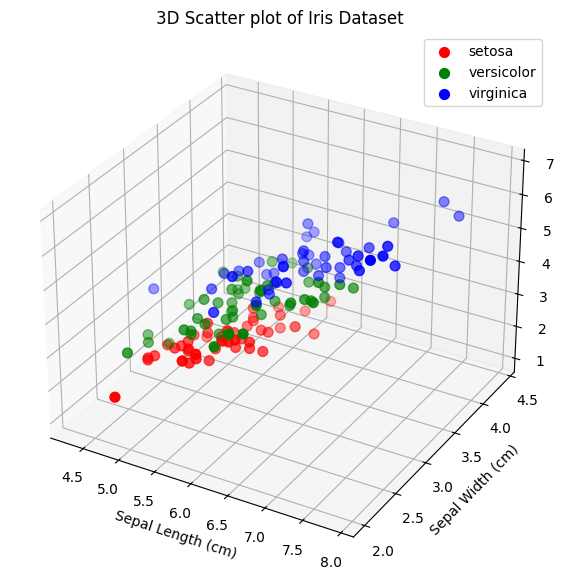

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris

# Cargar el conjunto de datos Iris
iris = load_iris()
X = iris.data  # Las características
y = iris.target  # Las etiquetas de las especies
species = iris.target_names  # Nombres de las especies

# Crear una figura 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Asignar colores para cada especie
colors = ['r', 'g', 'b']
for i, color in enumerate(colors):
    # Filtrar las muestras para cada especie
    ax.scatter(X[y == i, 0], X[y == i, 1], X[y == i, 2], color=color, label=species[i], s=50)

# Etiquetas de los ejes
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Sepal Width (cm)')
ax.set_zlabel('Petal Length (cm)')
ax.legend()
ax.set_title("3D Scatter plot of Iris Dataset")

plt.show()


In [2]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
import plotly.express as px
from sklearn.datasets import load_iris
import pandas as pd

# Cargar el conjunto de datos Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Crear un gráfico interactivo con Plotly faltando la columna petal width (cm)
fig = px.scatter_3d(df, 
                    x='sepal length (cm)', 
                    y='sepal width (cm)', 
                    z='petal length (cm)',
                    color=df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}),
                    labels={'color': 'Species'})

fig.update_layout(title="Interactive 3D Scatter Plot of Iris Dataset")
fig.show()


# Crear un gráfico interactivo con Plotly faltando la columna petal length (cm)
fig = px.scatter_3d(df, 
                    x='sepal length (cm)', 
                    y='sepal width (cm)', 
                    z='petal width (cm)',
                    color=df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}),
                    labels={'color': 'Species'})

fig.update_layout(title="Interactive 3D Scatter Plot of Iris Dataset")
fig.show()  


# Crear un gráfico interactivo con Plotly faltando la columna sepal length (cm)
fig = px.scatter_3d(df, 
                    x='sepal length (cm)', 
                    y='petal length (cm)', 
                    z='petal width (cm)',
                    color=df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}),
                    labels={'color': 'Species'})

fig.update_layout(title="Interactive 3D Scatter Plot of Iris Dataset")
fig.show()


# Crear un gráfico interactivo con Plotly faltando la columna sepal width (cm)
fig = px.scatter_3d(df, 
                    x='sepal width (cm)', 
                    y='petal length (cm)', 
                    z='petal width (cm)',
                    color=df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}),
                    labels={'color': 'Species'})

fig.update_layout(title="Interactive 3D Scatter Plot of Iris Dataset")
fig.show()

NameError: name 'plt' is not defined

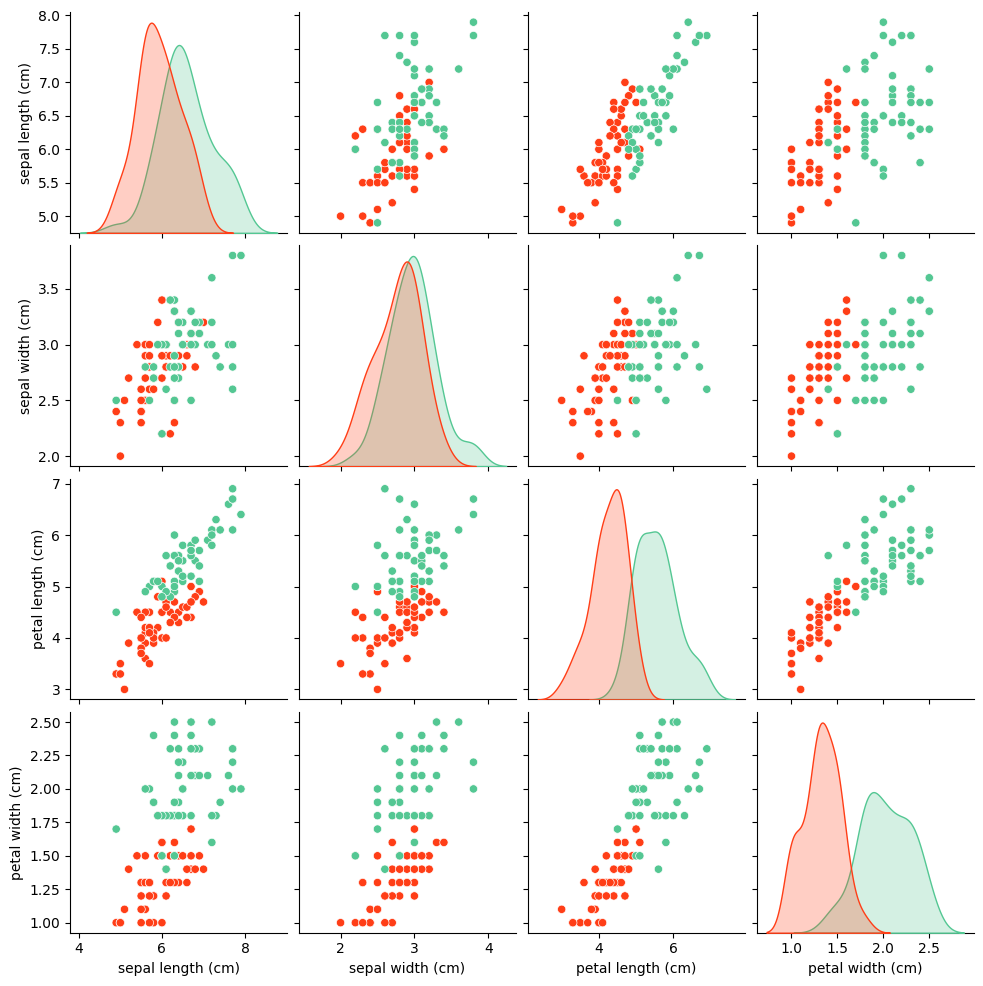

In [2]:
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris

# Cargar el conjunto de datos Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Filtrar solo las especies Versicolor y Virginica (las más difíciles de distinguir)
df = df[df['species'].isin([1, 2])]
df['species'] = df['species'].map({1: 'Versicolor', 2: 'Virginica'})

# definir colores para las especies. Usar los mismos que usa plotly en la grafica anterior
colors = {'Versicolor': '#FF3E17', 'Virginica': '#54c793'}

# Crear el gráfico de pares (pairplot) para comparar todas las combinaciones de características
pairplot = sns.pairplot(df, hue='species', palette=colors, diag_kind="kde") # , markers=["o", "s"]

# sin leyenda
pairplot._legend.remove()

plt.show()





# Flujo

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar
import scipy.stats as stats

# Cargar el conjunto de datos Iris
data = load_iris()
X = data.data
y = data.target

# tomar solo las especies virginica y versicolor
X = X[y != 0]
y = y[y != 0] - 1
labels = data.target_names[1:].tolist()

In [52]:
model_nb = GaussianNB()
model_knn = KNeighborsClassifier(n_neighbors=3)  # K=3 es común, puedes ajustar el valor

In [53]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

# Entrenar ambos modelos
model_nb.fit(X_train, y_train)
model_knn.fit(X_train, y_train)

# Predecir con ambos modelos en el conjunto de prueba
y_pred_nb = model_nb.predict(X_test)
y_pred_knn = model_knn.predict(X_test)

# McNemar test

In [47]:
confusion_matrix(y_test, y_pred_nb)

array([[15,  2],
       [ 2, 11]])

In [48]:
confusion_matrix(y_test, y_pred_knn)

array([[15,  2],
       [ 0, 13]])

In [57]:
def mcnemar_test(true_labels, pred1, pred2):
    # Count contingency table elements
    a = sum((true_labels == pred1) & (true_labels == pred2))
    b = sum((pred1 == true_labels) & (pred2 != true_labels))
    c = sum((pred1 != true_labels) & (pred2 == true_labels))
    d = sum((true_labels != pred1) & (true_labels != pred2))
    
    # Calculate McNemar test statistic
    chi_square = ((b - c) ** 2) / (b + c)
    
    return chi_square

chisquare_value = mcnemar_test(y_test, y_pred_knn, y_pred_nb)


In [58]:
# calcular el valor p de una prueba de McNemar para chi2 = 0.33 y un grado de libertad

p_value = 1 - stats.chi2.cdf(chisquare_value, 1)
print(p_value)

0.5637028616507731


# 2x5

In [65]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy import stats

# Instancias de los modelos
model1 = GaussianNB()
model2 = KNeighborsClassifier(n_neighbors=3)

# Configuración de la validación cruzada 5x2
kf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

In [86]:
lista = [1,2,3,1,2,3,1,2,3,1,2,3]


for _ in range(3):
    for train, test in kf.split(lista, lista):
        tempX = lista[train]
        print(tempX)

TypeError: only integer scalar arrays can be converted to a scalar index

In [104]:
train_index, test_index = kf.split(X, y)

X[train_index[0]]

array([[6.4, 3.2, 4.5, 1.5],
       [6.9, 3.1, 4.9, 1.5],
       [5.5, 2.3, 4. , 1.3],
       [5.7, 2.8, 4.5, 1.3],
       [6.3, 3.3, 4.7, 1.6],
       [4.9, 2.4, 3.3, 1. ],
       [6.6, 2.9, 4.6, 1.3],
       [6. , 2.2, 4. , 1. ],
       [5.6, 3. , 4.5, 1.5],
       [5.8, 2.7, 4.1, 1. ],
       [6.2, 2.2, 4.5, 1.5],
       [6.1, 2.8, 4.7, 1.2],
       [6.4, 2.9, 4.3, 1.3],
       [6.8, 2.8, 4.8, 1.4],
       [6.7, 3. , 5. , 1.7],
       [6. , 2.9, 4.5, 1.5],
       [5.5, 2.4, 3.8, 1.1],
       [5.8, 2.7, 3.9, 1.2],
       [6.7, 3.1, 4.7, 1.5],
       [6.3, 2.3, 4.4, 1.3],
       [5.5, 2.5, 4. , 1.3],
       [5. , 2.3, 3.3, 1. ],
       [5.7, 2.9, 4.2, 1.3],
       [5.1, 2.5, 3. , 1.1],
       [5.7, 2.8, 4.1, 1.3],
       [6.3, 3.3, 6. , 2.5],
       [5.8, 2.7, 5.1, 1.9],
       [6.3, 2.9, 5.6, 1.8],
       [6.5, 3. , 5.8, 2.2],
       [7.6, 3. , 6.6, 2.1],
       [7.3, 2.9, 6.3, 1.8],
       [6.4, 2.7, 5.3, 1.9],
       [6.8, 3. , 5.5, 2.1],
       [5.7, 2.5, 5. , 2. ],
       [7.7, 3

In [91]:
test

(array([0, 1, 5, 6, 7, 8]), array([ 2,  3,  4,  9, 10, 11]))

In [ ]:

# Lista para almacenar las diferencias de precisión
differences = []
accuracies_1 = []
accuracies_2 = []
variances = []

# Realizar 5 repeticiones de 2 particiones cada una
for index in range(5):
    kf = StratifiedKFold(n_splits=2, shuffle=True, random_state=index)

    for train_index, test_index in kf.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Entrenar y evaluar el primer modelo
        model1.fit(X_train, y_train)
        y_pred1 = model1.predict(X_test)
        acc1 = accuracy_score(y_test, y_pred1)

        # Entrenar y evaluar el segundo modelo
        model2.fit(X_train, y_train)
        y_pred2 = model2.predict(X_test)
        acc2 = accuracy_score(y_test, y_pred2)

        accuracies_1.append(acc1)
        accuracies_2.append(acc2)
        differences.append(acc2 - acc1)

    # Calcular la varianza
    

In [123]:

# Calcular la media de las diferencias
mean_diff = np.mean(differences)

for i in range(5):
    variances.append((differences[2*i] - mean_diff)**2 + (differences[2*i + 1] - mean_diff)**2)

variances

[np.float64(7.199999999999934e-05),
 np.float64(0.00039199999999999945),
 np.float64(0.0043919999999999975),
 np.float64(0.001831999999999997),
 np.float64(0.001351999999999993)]

In [126]:
t_stat = (differences[0]) / np.sqrt((1/5) * sum(variances))
t_stat

np.float64(0.4987546680538145)

In [127]:

# Calcular el valor de p
p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=5))

# Imprimir resultados
print(f'Estadístico t: {t_stat:.4f}')
print(f'Valor de p: {p_value:.4f}')

Estadístico t: 0.4988
Valor de p: 0.6391
